In [2]:
!pip install segmentation-models-pytorch
!pip install -U albumentations
!pip install --upgrade opencv-contrib-python

## Download Full Dataset

Market-1501 dataset :
https://www.kaggle.com/pengcw1/market-1501

In [3]:
!git clone https://github.com/parth1620/Person-Re-Id-Dataset

Cloning into 'Person-Re-Id-Dataset'...
remote: Enumerating objects: 12942, done.
remote: Counting objects: 100% (12942/12942), done.
remote: Compressing objects: 100% (12942/12942), done.
remote: Total 12942 (delta 0), reused 12942 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12942/12942), 27.68 MiB | 31.18 MiB/s, done.


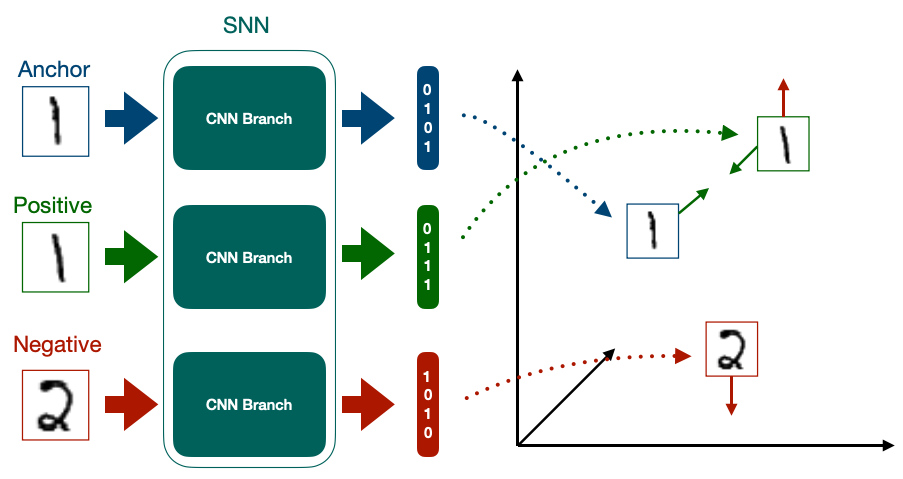

## Imports

In [4]:
import sys
sys.path.append('/content/Person-Re-Id-Dataset')

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import timm

import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader

from skimage import io
from sklearn.model_selection import train_test_split

from tqdm import tqdm

## Configurations

In [6]:
DATA_DIR = '/content/Person-Re-Id-Dataset/train/'
CSV_FILE = '/content/Person-Re-Id-Dataset/train.csv'

BATCH_SIZE = 32
LR = 0.001
EPOCHS = 15

DEVICE = 'cuda'

In [7]:
df = pd.read_csv(CSV_FILE)
df.head()

,Anchor,Negative,Positive
0,1420_c5s3_052165_01.jpg,1334_c6s3_061492_05.jpg,1420_c3s3_051678_01.jpg
1,1420_c3s3_061978_03.jpg,0234_c3s3_079494_02.jpg,1420_c6s3_085567_02.jpg
2,1420_c5s3_062565_05.jpg,0475_c2s1_122816_08.jpg,1420_c3s3_051653_01.jpg
3,1420_c6s3_085592_04.jpg,0662_c2s2_036662_05.jpg,1420_c1s6_013446_04.jpg
4,0663_c5s3_085987_03.jpg,1463_c2s3_098102_02.jpg,0663_c3s3_085544_06.jpg


In [8]:
row = df.iloc[4]

A_img = io.imread(DATA_DIR + row.Anchor)
P_img = io.imread(DATA_DIR + row.Positive)
N_img = io.imread(DATA_DIR + row.Negative)

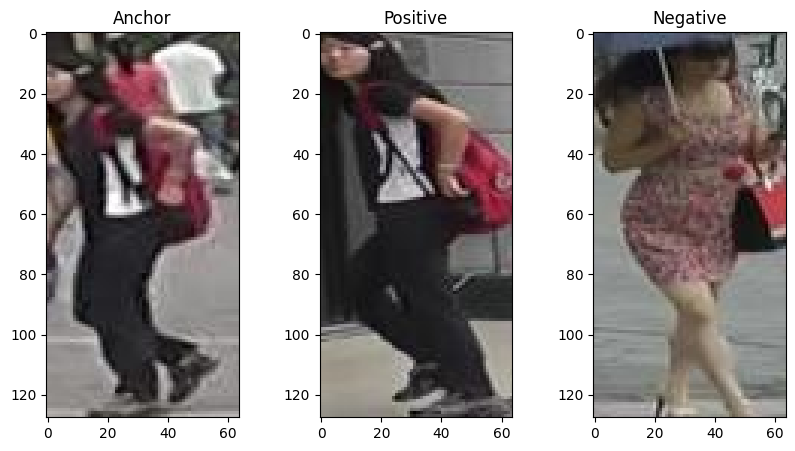

In [10]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 5))

ax1.set_title("Anchor")
ax1.imshow(A_img)

ax2.set_title("Positive")
ax2.imshow(P_img)

ax3.set_title("Negative")
ax3.imshow(N_img)

plt.show()

In [11]:
train_df, valid_df = train_test_split(df, test_size=0.20, random_state=42)

## Create APN Dataset

In [12]:
class APN_Dataset(Dataset):

    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        A_img = io.imread(DATA_DIR + row.Anchor)
        P_img = io.imread(DATA_DIR + row.Positive)
        N_img = io.imread(DATA_DIR + row.Negative)

        A_img = torch.from_numpy(A_img).permute(2, 0, 1) / 255.0
        P_img = torch.from_numpy(P_img).permute(2, 0, 1) / 255.0
        N_img = torch.from_numpy(N_img).permute(2, 0, 1) / 255.0

        return A_img, P_img, N_img

In [13]:
trainset = APN_Dataset(train_df)
validset = APN_Dataset(valid_df)

print(f"Size of trainset : {len(trainset)}")
print(f"Size of validset : {len(validset)}")

Size of trainset : 3200
Size of validset : 800


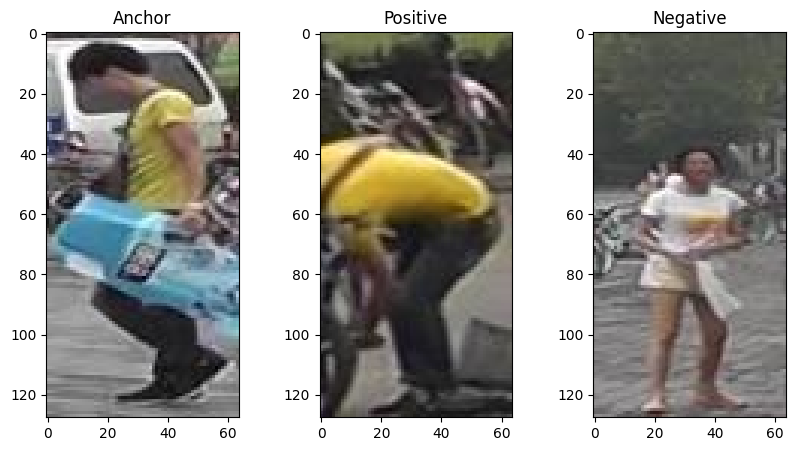

In [15]:
idx = 40
A,P,N = trainset[idx]

f, (ax1, ax2, ax3) = plt.subplots(1,3,figsize= (10,5))

ax1.set_title('Anchor')
ax1.imshow(A.numpy().transpose((1,2,0)), cmap = 'gray')

ax2.set_title('Positive')
ax2.imshow(P.numpy().transpose((1,2,0)), cmap = 'gray')

ax3.set_title('Negative')
ax3.imshow(N.numpy().transpose((1,2,0)), cmap = 'gray')

plt.show()

## Load Dataset into Batches

In [16]:
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
validloader = DataLoader(validset, batch_size=BATCH_SIZE)

In [17]:
print(f"No. of batches in trainloader : {len(trainloader)}")
print(f"No. of batches in validloader : {len(validloader)}")

No. of batches in trainloader : 100
No. of batches in validloader : 25


In [18]:
for A, P, N in trainloader:
  break;

print(f"One image batch shape : {A.shape}")

One image batch shape : torch.Size([32, 3, 128, 64])


## Create Model

In [19]:
class APN_Model(nn.Module):

    def __init__(self, emb_size=512):
        super(APN_Model, self).__init__()

        self.efficientnet = timm.create_model('efficientnet_b0', pretrained=True)
        self.efficientnet.classifier = nn.Linear(
            in_features=self.efficientnet.classifier.in_features,
            out_features=emb_size
        )

    def forward(self, images):
        embeddings = self.efficientnet(images)
        return embeddings

In [21]:
model = APN_Model()
model.to(DEVICE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

APN_Model(
  (efficientnet): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw):

## Create Train and Eval function

In [22]:
def train_fn(model, dataloader, optimizer, criterion):

    model.train()  # ON Dropout
    total_loss = 0.0

    for A, P, N in tqdm(dataloader):

        A, P, N = A.to(DEVICE), P.to(DEVICE), N.to(DEVICE)

        A_embs = model(A)
        P_embs = model(P)
        N_embs = model(N)

        loss = criterion(A_embs, P_embs, N_embs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [23]:
def eval_fn(model, dataloader, criterion):

    model.eval()  # OFF Dropout
    total_loss = 0.0

    with torch.no_grad():
      for A, P, N in tqdm(dataloader):

          A, P, N = A.to(DEVICE), P.to(DEVICE), N.to(DEVICE)

          A_embs = model(A)
          P_embs = model(P)
          N_embs = model(N)

          loss = criterion(A_embs, P_embs, N_embs)

          total_loss += loss.item()

      return total_loss / len(dataloader)

In [24]:
criterion = nn.TripletMarginLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

## Create Training Loop

In [25]:
best_valid_loss = np.inf

for i in range(EPOCHS):

    train_loss = train_fn(model, trainloader, optimizer, criterion)
    valid_loss = eval_fn(model, validloader, criterion)

    if valid_loss < best_valid_loss:
        torch.save(model.state_dict(), 'best_model.pt')
        best_valid_loss = valid_loss
        print("SAVED_WEIGHTS_SUCCESS")

    print(f"EPOCHS : {i+1} train_loss : {train_loss} valid_loss : {valid_loss}")

100%|██████████| 25/25 [00:02<00:00,  8.76it/s]


SAVED_WEIGHTS_SUCCESS
EPOCHS : 1 train_loss : 0.6015136334300041 valid_loss : 0.469435396194458


100%|██████████| 25/25 [00:03<00:00,  7.73it/s]


EPOCHS : 2 train_loss : 0.330227702409029 valid_loss : 0.4764989638328552


100%|██████████| 25/25 [00:03<00:00,  7.98it/s]


...

SAVED_WEIGHTS_SUCCESS
EPOCHS : 13 train_loss : 0.046148508042097094 valid_loss : 0.12832874417304993


100%|██████████| 25/25 [00:02<00:00,  8.75it/s]


EPOCHS : 14 train_loss : 0.03641646698117256 valid_loss : 0.14306398302316667


100%|██████████| 25/25 [00:03<00:00,  8.11it/s]

EPOCHS : 15 train_loss : 0.028971834927797317 valid_loss : 0.1569398134946823


## Get Anchor Embeddings

In [33]:
def get_encoding_csv(model, anc_img_names):
    anc_img_names_arr = np.array(anc_img_names)
    encodings = []

    model.eval()
    with torch.no_grad():
        for i in tqdm(anc_img_names_arr):
            A = io.imread(DATA_DIR + i)
            A = torch.from_numpy(A).permute(2, 0, 1) / 255.0
            A = A.to(DEVICE)
            A_enc = model(A.unsqueeze(0))
            encodings.append(A_enc.squeeze().cpu().detach().numpy())

    encodings = np.array(encodings)
    df_enc = pd.DataFrame(encodings)
    df_enc.insert(0, 'Anchor', anc_img_names_arr)

    return df_enc

In [35]:
model.load_state_dict(torch.load('best_model.pt'))
df_enc = get_encoding_csv(model, df['Anchor'])

100%|██████████| 4000/4000 [00:42<00:00, 95.03it/s]


In [36]:
df_enc.to_csv('database.csv', index = False)
df_enc.head()

,Anchor,0,1,2,3,4,5,6,7,8,...,502,503,504,505,506,507,508,509,510,511
0,1420_c5s3_052165_01.jpg,0.426167,0.159204,-1.209746,-0.888000,0.376976,-0.492457,0.251572,-0.051846,0.264467,...,0.941554,0.135883,-0.597133,-0.243375,0.278429,-0.063485,-0.397263,0.843681,-0.771590,0.128768
1,1420_c3s3_061978_03.jpg,0.122484,0.032906,-0.784298,-0.747669,0.422481,-0.390188,0.018437,0.470132,0.222882,...,0.885100,0.120727,-0.498545,-0.247743,0.335819,-0.332586,-0.216572,0.882515,-0.432717,-0.079123
2,1420_c5s3_062565_05.jpg,0.288394,0.116723,-0.841362,-0.750147,0.306020,-0.524632,0.209589,0.375478,0.268987,...,1.131196,0.024804,-0.661879,-0.121491,0.299682,-0.279897,-0.288538,1.025495,-0.533757,-0.067932
3,1420_c6s3_085592_04.jpg,-0.380222,0.274470,-0.490189,-0.578417,0.510288,-0.474109,0.386885,0.401542,0.323733,...,1.351808,-0.293756,-0.501678,0.104449,0.414989,-0.445391,-0.435967,1.085227,-0.491735,-0.238874
4,0663_c5s3_085987_03.jpg,-0.702601,0.606972,1.009095,0.671730,0.081116,-0.200427,0.195830,-0.299722,0.134530,...,0.464738,0.193117,0.304391,1.295759,0.177305,-0.481286,0.418468,0.115658,-0.291977,0.139915


## Inference

In [37]:
def euclidean_dist(img_enc, anc_enc_arr):
  dist = np.sqrt(np.dot(img_enc - anc_enc_arr, (img_enc - anc_enc_arr).T))
  return dist

In [51]:
idx = 4

# Safely extract the image name string from the first column
img_name = df_enc['Anchor'].iloc[idx]
if isinstance(img_name, pd.Series):
    img_name = img_name.iloc[0]

img_path = DATA_DIR + img_name

img = io.imread(img_path)
img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0

model.eval()
with torch.no_grad():
  img = img.to(DEVICE)
  img_enc = model(img.unsqueeze(0))
  img_enc = img_enc.detach().cpu().numpy()

In [52]:
anc_enc_arr = df_enc.iloc[:, 1:].to_numpy()
anc_img_names = df_enc['Anchor']

In [53]:
distance = []

for i in range(anc_enc_arr.shape[0]):
    dist = euclidean_dist(img_enc, anc_enc_arr[i:i+1, :])
    distance = np.append(distance, dist)

In [54]:
closest_idx = np.argsort(distance)

/usr/local/lib/python3.12/dist-packages/networkx/drawing/layout.py:987: RuntimeWarning: divide by zero encountered in divide
  costargs = (np, 1 / (dist_mtx + np.eye(dist_mtx.shape[0]) * 1e-3), meanwt, dim)


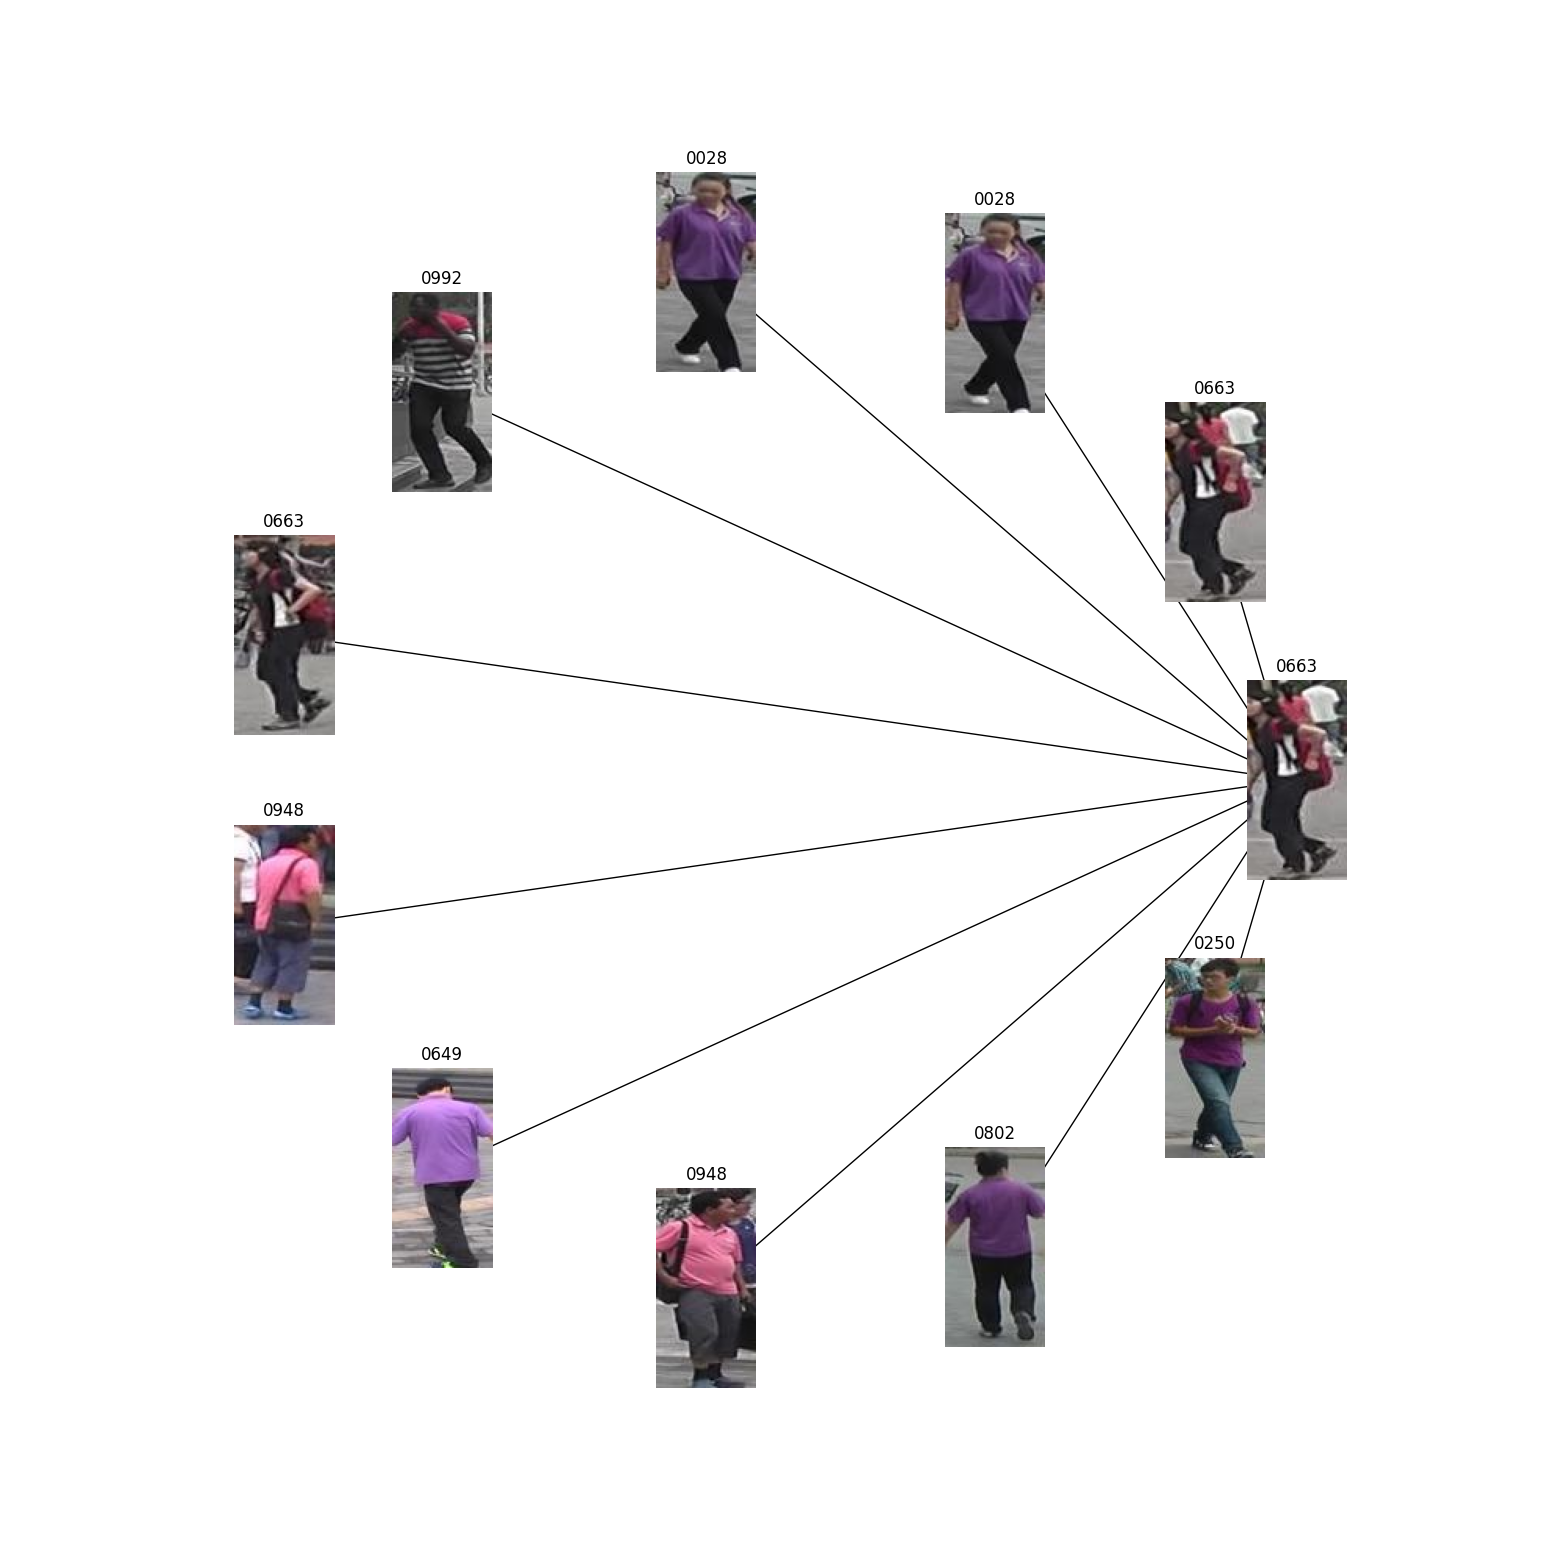

In [58]:
from utils import plot_closest_imgs

plot_closest_imgs(anc_img_names, DATA_DIR, img, img_path, closest_idx, distance, no_of_closest = 10)

plt.show()